In [1]:
import os, time, hashlib
from datetime import datetime, timedelta
import pandas as pd, numpy as np
import finnhub, requests, yfinance as yf
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from scipy.special import softmax
from pandas.tseries.offsets import BDay

In [2]:
# ------------------- CONFIG -------------------

# FINNHUB_API_KEY = "d2arrjpr01qgk9ugd2ugd2arrjpr01qgk9ugd2v0"
# MARKETAUX_API_KEY = "3Ej6emn1jO1MzOjziTsrCacnbQvx6pjueugwiMb4"
SYMBOL = "NVDA"
CUTOVER_DATE = datetime(2024, 8, 28).date()  # use Finnhub on or after
YEAR_START = "2023-07-01"
YEAR_END = "2025-08-01"
LAG_DAYS = [0, 1, 3, 7, 14]
OUT_DIR = "./outputs"
os.makedirs(OUT_DIR, exist_ok=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# API endpoints
MARKETAUX_URL = "https://api.marketaux.com/v1/news/all"

# ------------------- INIT CLIENT -------------------

# finnhub_client = finnhub.Client(api_key=FINNHUB_API_KEY)

# Data Loading and Preprocessing

In [ ]:
# ------------------- 1) FETCH NEWS -------------------

all_news = []
start = datetime.strptime(YEAR_START, "%Y-%m-%d")
end = datetime.strptime(YEAR_END, "%Y-%m-%d")
delta = timedelta(days=7)

print("Fetching NVDA news using Marketaux (before cutover) and Finnhub (after)...")

while start <= end:
    batch_end = min(start + delta, end)
    date_from, date_to = start.date(), batch_end.date()

    #  if before cutoff date — use Marketaux
    if date_to < CUTOVER_DATE:
        # Marketaux request
        params = {
            "api_token": MARKETAUX_API_KEY,
            "symbols": SYMBOL,
            "published_after": f"{date_from}T00:00:00",
            "published_before": f"{date_to}T23:59:59",
            "limit": 1000
        }
        try:
            resp = requests.get(MARKETAUX_URL, params=params, timeout=10)
            resp.raise_for_status()
            data = resp.json().get("data", [])
            print(f"Marketaux: {len(data)} articles {date_from}→{date_to}")
            for a in data:
                all_news.append({
                    "id": a["uuid"],
                    "timestamp": a["published_at"],
                    "headline": a["title"],
                    "summary": a["description"],
                    "url": a["url"],
                    "source": "marketaux"
                })
        except Exception as e:
            print(f"Marketaux error {date_from}→{date_to}: {e}")

    #  if on/after cutoff date — use Finnhub
    else:
        try:
            fh = finnhub_client.company_news(SYMBOL, _from=str(date_from), to=str(date_to))
            print(f"Finnhub: {len(fh)} articles {date_from}→{date_to}")
            for a in fh:
                all_news.append({
                    "id": a["id"],
                    "timestamp": pd.to_datetime(a["datetime"], unit="s", utc=True),
                    "headline": a["headline"],
                    "summary": a.get("summary", ""),
                    "url": a.get("url", ""),
                    "source": "finnhub"
                })
        except Exception as e:
            print(f"Finnhub error {date_from}→{date_to}: {e}")

    start = batch_end + timedelta(days=1)
    time.sleep(0.3)

# ------------------- Deduplicate & Normalize -------------------

df = pd.DataFrame(all_news)
# hash headline+summary+timestamp
df["ts_str"] = df["timestamp"].astype(str)
df["hash"] = (df["headline"].fillna("") + df["summary"].fillna("") + df["ts_str"]).apply(
    lambda x: hashlib.sha1(x.encode()).hexdigest()
)
df = df.drop_duplicates(subset=["hash"]).reset_index(drop=True)
df["published_at"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")
df = df.dropna(subset=["published_at"])
df["pub_date"] = df["published_at"].dt.date
df["text"] = (df["headline"] + ". " + df["summary"]).str.strip()

print(f"Total news after deduplication: {len(df)}")
print("Date range:", df['pub_date'].min(), "→", df['pub_date'].max())

df.to_csv(os.path.join(OUT_DIR, "news_combined.csv"), index=False)

In [ ]:
# ------------------- 2) Sentiment Scoring -------------------

print("Scoring sentiment (FinBERT)...")
tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")
model = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert").to(DEVICE)

def score(text):
    if not text:
        return (0,0,1,0)
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512).to(DEVICE)
    with torch.no_grad():
        out = model(**inputs)
    neg, neu, pos = softmax(out.logits.cpu().numpy()[0])
    return pos-neg, pos, neu, neg

sent = df["text"].apply(lambda t: pd.Series(score(t), index=["sent_net","sent_pos","sent_neu","sent_neg"]))
df = pd.concat([df, sent], axis=1)
df.to_csv(os.path.join(OUT_DIR, "news_with_sentiment.csv"), index=False)
print("Sentiment scoring done.")

In [ ]:
# ------------------- 3) Fetch Prices -------------------

start_dt = (pd.to_datetime(YEAR_START) - timedelta(days=5)).strftime("%Y-%m-%d")
end_price = df["pub_date"].max() + BDay(max(LAG_DAYS)+5)
print("Fetching historical prices:", start_dt, "→", end_price.date())
prices = yf.download(SYMBOL, start=start_dt, end=end_price.strftime("%Y-%m-%d"), interval="1d")
prices.reset_index(inplace=True)
prices["date"] = pd.to_datetime(prices["Date"]).dt.date
prices = prices[["date","Open","High","Low","Close","Volume"]]
prices.to_csv(os.path.join(OUT_DIR, "price_data.csv"), index=False)
print("Price data saved.")

# Next: compute lags, directional labels, correlation, etc. (unchanged)

In [ ]:
from scipy import stats
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [ ]:
# -------------------------
# 4) Compute lagged pct changes per news article
# -------------------------

# Use price DataFrame saved earlier
df_price = prices.copy()
df_price["date"] = pd.to_datetime(df_price["date"])
df_price = df_price.sort_values("date").reset_index(drop=True)
trading_dates = list(sorted(df_price["date"].unique()))

def get_trading_date_on_or_after(input_date):
    input_date = pd.Timestamp(input_date)
    for d in trading_dates:
        if d >= input_date:
            return d
    return None

def get_close_on_date(date):
    match = df_price.loc[df_price["date"] == date, "Close"]
    if len(match) == 0:
        return None
    return float(match.iloc[0])

def add_trading_days(start_date, days):
    if start_date not in trading_dates:
        start_date = get_trading_date_on_or_after(start_date)
    if start_date is None:
        return None
    try:
        start_idx = trading_dates.index(start_date)
    except ValueError:
        return None
    target_idx = start_idx + days
    if target_idx >= len(trading_dates):
        return None
    return trading_dates[target_idx]

records = []
price_min_date = df_price["date"].min()
price_max_date = df_price["date"].max()
print(f"Price data covers from {price_min_date.date()} to {price_max_date.date()}")

for _, r in df.iterrows():
    pub_date = pd.to_datetime(r["pub_date"])
    if pub_date < price_min_date:
        print(f"Warning: News date {pub_date.date()} before price data start {price_min_date.date()}. Skipping.")
        continue
    if pub_date > price_max_date:
        print(f"Warning: News date {pub_date.date()} after price data end {price_max_date.date()}. Skipping.")
        continue

    base_td = get_trading_date_on_or_after(pub_date)
    if base_td is None:
        print(f"Warning: No trading date found on/after news date {pub_date.date()}. Skipping.")
        continue
    base_close = get_close_on_date(base_td)
    if base_close is None:
        print(f"Warning: No close price for base trading date {base_td.date()}. Skipping.")
        continue

    rec = {
        "id": r.get("id", None),
        "published_at": r.get("published_at", None),
        "pub_date": pub_date,
        "base_trading_date": base_td,
        "base_close": base_close,
        "sent_net": r["sent_net"],
        "sent_pos": r["sent_pos"],
        "sent_neu": r["sent_neu"],
        "sent_neg": r["sent_neg"],
        "headline": r.get("headline", ""),
        "url": r.get("url", ""),
        "source": r.get("source", "")
    }

    for lag in LAG_DAYS:
        target_date = add_trading_days(base_td, lag)
        if target_date is None:
            print(f"Note: Lag {lag}d out of range for article on {pub_date.date()}.")
            rec[f"close_{lag}d"] = np.nan
            rec[f"pct_change_{lag}d"] = np.nan
            rec[f"trading_date_{lag}d"] = None
            continue

        close_price = get_close_on_date(target_date)
        if close_price is None:
            print(f"Warning: No price for lag {lag}d date {target_date.date()} (article {pub_date.date()}).")
            rec[f"close_{lag}d"] = np.nan
            rec[f"pct_change_{lag}d"] = np.nan
            rec[f"trading_date_{lag}d"] = None
            continue

        rec[f"close_{lag}d"] = close_price
        rec[f"pct_change_{lag}d"] = (close_price - base_close) / base_close
        rec[f"trading_date_{lag}d"] = target_date

    records.append(rec)

df_results = pd.DataFrame(records)
df_results.to_csv(os.path.join(OUT_DIR, "nvda_news_lagged_results.csv"), index=False)
print(f"Saved per-article lagged results. Processed articles: {len(df_results)}")

In [ ]:
# ================================
# Standalone Step 4: recompute lagged pct changes
# using existing price_data.csv and news_with_sentiment.csv
# ================================
import os
import numpy as np
import pandas as pd
from datetime import datetime

OUT_DIR = "./outputs"
LAG_DAYS = [1, 3, 7, 14, 30]

price_path = os.path.join(OUT_DIR, "price_data.csv")
news_sent_path = os.path.join(OUT_DIR, "news_with_sentiment.csv")

df_price = pd.read_csv(price_path)
df_price["date"] = pd.to_datetime(df_price["date"])
df_price = df_price.sort_values("date").reset_index(drop=True)

df = pd.read_csv(news_sent_path)
df["pub_date"] = pd.to_datetime(df["pub_date"])

trading_dates = list(sorted(df_price["date"].unique()))

def get_trading_date_on_or_after(input_date):
    input_date = pd.Timestamp(input_date)
    for d in trading_dates:
        if d >= input_date:
            return d
    return None

def get_close_on_date(date):
    match = df_price.loc[df_price["date"] == date, "Close"]
    if len(match) == 0:
        return None
    return float(match.iloc[0])

def add_trading_days(start_date, days):
    if start_date not in trading_dates:
        start_date = get_trading_date_on_or_after(start_date)
    if start_date is None:
        return None
    try:
        start_idx = trading_dates.index(start_date)
    except ValueError:
        return None
    target_idx = start_idx + days
    if target_idx >= len(trading_dates):
        return None
    return trading_dates[target_idx]

records = []
price_min_date = df_price["date"].min()
price_max_date = df_price["date"].max()
print(f"Price data covers from {price_min_date.date()} to {price_max_date.date()}")

for _, r in df.iterrows():
    pub_date = pd.to_datetime(r["pub_date"])
    if pub_date < price_min_date or pub_date > price_max_date:
        continue

    base_td = get_trading_date_on_or_after(pub_date)
    if base_td is None:
        continue
    base_close = get_close_on_date(base_td)
    if base_close is None:
        continue

    rec = {
        "id": r.get("id", None),
        "published_at": r.get("published_at", None),
        "pub_date": pub_date,
        "base_trading_date": base_td,
        "base_close": base_close,
        "sent_net": r["sent_net"],
        "sent_pos": r["sent_pos"],
        "sent_neu": r["sent_neu"],
        "sent_neg": r["sent_neg"],
        "headline": r.get("headline", ""),
        "url": r.get("url", ""),
        "source": r.get("source", "")
    }

    for lag in LAG_DAYS:
        target_date = add_trading_days(base_td, lag)
        if target_date is None:
            rec[f"close_{lag}d"] = np.nan
            rec[f"pct_change_{lag}d"] = np.nan
            rec[f"trading_date_{lag}d"] = None
            continue

        close_price = get_close_on_date(target_date)
        if close_price is None:
            rec[f"close_{lag}d"] = np.nan
            rec[f"pct_change_{lag}d"] = np.nan
            rec[f"trading_date_{lag}d"] = None
            continue

        rec[f"close_{lag}d"] = close_price
        rec[f"pct_change_{lag}d"] = (close_price - base_close) / base_close
        rec[f"trading_date_{lag}d"] = target_date

    records.append(rec)

df_results = pd.DataFrame(records)
out_path = os.path.join(OUT_DIR, "nvda_news_lagged_results.csv")
df_results.to_csv(out_path, index=False)
print(f"Saved per-article lagged results -> {out_path}, Processed articles: {len(df_results)}")

In [ ]:
# -------------------------
# 5) Analysis: correlation, regression, directional accuracy
# -------------------------
print("Analyzing results by lag...")
summary_rows = []

for lag in LAG_DAYS:
    col = f"pct_change_{lag}d"

    if "sent_net" not in df_results.columns or col not in df_results.columns:
        print(f"Skipping lag {lag}d — missing 'sent_net' or '{col}' in df_results.")
        continue

    tmp = df_results[["sent_net", col]].dropna()
    n = len(tmp)

    if n >= 5:
        r_val, p_val = stats.pearsonr(tmp["sent_net"], tmp[col])
        X = tmp[["sent_net"]].values.reshape(-1, 1)
        y = tmp[col].values
        lr = LinearRegression().fit(X, y)
        coef = float(lr.coef_[0])
        intercept = float(lr.intercept_)
        r2 = float(lr.score(X, y))
    else:
        r_val = p_val = coef = intercept = r2 = np.nan

    tmp_dir = tmp.assign(
        sent_dir=np.sign(tmp["sent_net"]),
        price_dir=np.sign(tmp[col])
    )
    tmp_dir = tmp_dir[tmp_dir["sent_dir"] != 0]
    accuracy = (tmp_dir["sent_dir"] == tmp_dir["price_dir"]).mean() if len(tmp_dir) > 0 else np.nan

    summary_rows.append({
        "lag_days": lag,
        "n": n,
        "pearson_r": r_val,
        "p_value": p_val,
        "reg_coef": coef,
        "reg_intercept": intercept,
        "reg_r2": r2,
        "directional_accuracy": accuracy
    })

df_summary = pd.DataFrame(summary_rows).sort_values("lag_days")
if not df_summary.empty:
    summary_csv = os.path.join(OUT_DIR, "nvda_lag_summary.csv")
    df_summary.to_csv(summary_csv, index=False)
    print("Saved lag summary ->", summary_csv)
    print(df_summary)
else:
    print("No valid lag results to save.")

In [ ]:
# ================================
# Standalone Step 5: Analysis using existing lag file
# (no need to rerun steps 1–3 if CSVs already exist)
# ================================
import os
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.linear_model import LinearRegression

OUT_DIR = "./outputs"

# --- Load precomputed lagged results ---
lag_file = os.path.join(OUT_DIR, "nvda_news_lagged_results.csv")
if not os.path.exists(lag_file):
    raise FileNotFoundError(
        f"{lag_file} not found. You must run steps 1–4 at least once to create it."
    )

df_results = pd.read_csv(lag_file)

# Optional: ensure numeric types
df_results["sent_net"] = pd.to_numeric(df_results["sent_net"], errors="coerce")
for lag in LAG_DAYS:
    col = f"pct_change_{lag}d"
    if col in df_results.columns:
        df_results[col] = pd.to_numeric(df_results[col], errors="coerce")

print("Analyzing results by lag...")
summary_rows = []

for lag in LAG_DAYS:
    col = f"pct_change_{lag}d"

    if "sent_net" not in df_results.columns or col not in df_results.columns:
        print(f"Skipping lag {lag}d — missing 'sent_net' or '{col}' in df_results.")
        continue

    tmp = df_results[["sent_net", col]].dropna()
    n = len(tmp)

    if n >= 5:
        r_val, p_val = stats.pearsonr(tmp["sent_net"], tmp[col])
        X = tmp[["sent_net"]].values.reshape(-1, 1)
        y = tmp[col].values
        lr = LinearRegression().fit(X, y)
        coef = float(lr.coef_[0])
        intercept = float(lr.intercept_)
        r2 = float(lr.score(X, y))
    else:
        r_val = p_val = coef = intercept = r2 = np.nan

    tmp_dir = tmp.assign(
        sent_dir=np.sign(tmp["sent_net"]),
        price_dir=np.sign(tmp[col])
    )
    tmp_dir = tmp_dir[tmp_dir["sent_dir"] != 0]
    accuracy = (tmp_dir["sent_dir"] == tmp_dir["price_dir"]).mean() if len(tmp_dir) > 0 else np.nan

    summary_rows.append({
        "lag_days": lag,
        "n": n,
        "pearson_r": r_val,
        "p_value": p_val,
        "reg_coef": coef,
        "reg_intercept": intercept,
        "reg_r2": r2,
        "directional_accuracy": accuracy
    })

df_summary = pd.DataFrame(summary_rows).sort_values("lag_days")
if not df_summary.empty:
    summary_csv = os.path.join(OUT_DIR, "nvda_lag_summary.csv")
    df_summary.to_csv(summary_csv, index=False)
    print("Saved lag summary ->", summary_csv)
    print(df_summary)
else:
    print("No valid lag results to save.")

In [ ]:
# -------------------------
# 6) Compute per-article best lag
# -------------------------
def best_lag_info(row):
    vals = row[[f"pct_change_{lag}d" for lag in LAG_DAYS]].abs()
    vals = vals.dropna()
    if vals.empty:
        return (None, np.nan)
    best_col = vals.idxmax()
    best_lag = int(best_col.split("_")[2].replace("d",""))
    best_val = row[best_col]
    return (best_lag, best_val)

df_results["best_lag_days"] = df_results.apply(lambda r: best_lag_info(r)[0], axis=1)
df_results["best_lag_pct_change"] = df_results.apply(lambda r: best_lag_info(r)[1], axis=1)
df_results.to_csv(os.path.join(OUT_DIR, "nvda_news_lagged_results_with_bestlag.csv"), index=False)
print("Saved per-article best-lag file.")

In [ ]:
# -------------------------
# 7) Plots
# -------------------------
plt.figure(figsize=(8,5))
plt.plot(df_summary["lag_days"], df_summary["pearson_r"], marker="o")
plt.xlabel("Lag after news (days)")
plt.ylabel("Pearson correlation (sent_net vs pct_change)")
plt.title("NVDA: sentiment vs pct change correlation by lag")
plt.grid(True)
plt.savefig(os.path.join(OUT_DIR, "correlation_vs_lag.png"), dpi=200)
plt.close()

plt.figure(figsize=(8,5))
plt.bar(df_summary["lag_days"].astype(str), df_summary["directional_accuracy"])
plt.xlabel("Lag (days)")
plt.ylabel("Directional accuracy (fraction)")
plt.title("Direction accuracy of sentiment prediction by lag")
plt.grid(axis="y")
plt.savefig(os.path.join(OUT_DIR, "directional_accuracy_by_lag.png"), dpi=200)
plt.close()

print("Plots saved in", OUT_DIR)
print("Done.")

# Modeling

In [3]:
# --------- load prerequisites from disk (so we don't need steps 1–3) ---------
df_results = pd.read_csv(os.path.join(OUT_DIR, "nvda_news_lagged_results.csv"))
df_price   = pd.read_csv(os.path.join(OUT_DIR, "price_data.csv"))

In [4]:
# ================================
# 8) FEATURE ENGINEERING (standalone daily panel)
# ================================
import os
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

# --- Load from saved CSVs (no need to rerun steps 1–3) ---
price_file = os.path.join(OUT_DIR, "price_data.csv")
lags_file  = os.path.join(OUT_DIR, "nvda_news_lagged_results.csv")

df_price = pd.read_csv(price_file)
df_results = pd.read_csv(lags_file)

# --- Basic cleaning / typing ---
# Dates
df_price["date"] = pd.to_datetime(df_price["date"])
df_results["pub_date"] = pd.to_datetime(df_results["pub_date"])

# Numeric price columns
price_num_cols = ["Open", "High", "Low", "Close", "Volume"]
for c in price_num_cols:
    if c in df_price.columns:
        df_price[c] = pd.to_numeric(df_price[c], errors="coerce")

# Numeric sentiment columns (if present)
for c in ["sent_net", "sent_pos", "sent_neu", "sent_neg"]:
    if c in df_results.columns:
        df_results[c] = pd.to_numeric(df_results[c], errors="coerce")

# --- aggregate daily sentiment from articles ---
df_results["pub_date"] = df_results["pub_date"].dt.normalize()

news_day = (
    df_results
    .groupby("pub_date")
    .agg(
        sent_net_mean=("sent_net", "mean"),
        sent_net_sum=("sent_net", "sum"),
        sent_pos_mean=("sent_pos", "mean"),
        sent_neg_mean=("sent_neg", "mean"),
        n_articles=("id", "count")
    )
    .sort_index()
    .reset_index()
)

# --- price features ---
px = df_price.copy()
px["date"] = px["date"].dt.normalize()
px = px.sort_values("date").rename(columns={"Close": "close"}).set_index("date")

# returns & vol
px["ret_1d"]  = px["close"].pct_change(1)
px["ret_5d"]  = px["close"].pct_change(5)
px["ret_10d"] = px["close"].pct_change(10)
px["vol_10d"] = px["ret_1d"].rolling(10).std()
px["vol_20d"] = px["ret_1d"].rolling(20).std()

# flatten multiindex columns in px (defensive)
if isinstance(px.columns, pd.MultiIndex):
    px.columns = ["_".join([str(c) for c in col]).strip("_") for col in px.columns]

# ensure news_day index is 'date'
news_day = news_day.rename(columns={"pub_date": "date"}).set_index("date")

# merge features
feat = px.join(news_day, how="left")

# fill no-news days with zeros (no news signal that day)
for c in ["sent_net_mean", "sent_net_sum", "sent_pos_mean", "sent_neg_mean", "n_articles"]:
    if c in feat.columns:
        feat[c] = feat[c].fillna(0)

# --- future label horizons ---
HORIZONS = [1, 3, 5, 10]  # trading days ahead

# auto-detect close column (handles "close" or "close_NVDA" cases)
close_candidates = [c for c in feat.columns if c.startswith("close")]
if len(close_candidates) == 0:
    raise ValueError(f"No 'close*' column found in feat.columns: {feat.columns.tolist()}")
close_col = close_candidates[0]
print(f"Using close column: {close_col}")

for h in HORIZONS:
    # return over next h days
    feat[f"label_ret_{h}d"] = feat[close_col].shift(-h) / feat[close_col] - 1.0
    
    # 3-class direction label: -1, 0, +1 (with neutral band)
    band = 0.002  # +/- 0.2% as neutral band
    lab = feat[f"label_ret_{h}d"].apply(
        lambda r: 1 if r > band else (-1 if r < -band else 0)
    )
    feat[f"label_dir_{h}d"] = lab

feat = feat.dropna().copy()

print("Feature panel 'feat' ready. Shape:", feat.shape)
print("Columns:", feat.columns.tolist())

Using close column: close
Feature panel 'feat' ready. Shape: (528, 23)
Columns: ['Open', 'High', 'Low', 'close', 'Volume', 'ret_1d', 'ret_5d', 'ret_10d', 'vol_10d', 'vol_20d', 'sent_net_mean', 'sent_net_sum', 'sent_pos_mean', 'sent_neg_mean', 'n_articles', 'label_ret_1d', 'label_dir_1d', 'label_ret_3d', 'label_dir_3d', 'label_ret_5d', 'label_dir_5d', 'label_ret_10d', 'label_dir_10d']


In [5]:
# ================================
# 9) Binary direction dataset for H = 1 day
# ================================

H_BIN = 1   # <-- we focus on 1 trading day ahead

label_col_3class = f"label_dir_{H_BIN}d"
if label_col_3class not in feat.columns:
    raise ValueError(f"{label_col_3class} not found in feat. Run feature-engineering first.")

# Work on a copy
bin_df = feat.copy()

# Filter out neutral days (label_dir == 0)
mask_non_neutral = bin_df[label_col_3class] != 0
bin_df = bin_df.loc[mask_non_neutral].copy()

print(f"[H={H_BIN}d] Total days before neutral filter: {len(feat)}")
print(f"[H={H_BIN}d] Total days after removing neutral band: {len(bin_df)}")

# Map -1 -> 0 (down), +1 -> 1 (up)
bin_df["y_bin"] = bin_df[label_col_3class].map({-1: 0, 1: 1})

print("Class distribution (0=down, 1=up):")
print(bin_df["y_bin"].value_counts())


[H=1d] Total days before neutral filter: 528
[H=1d] Total days after removing neutral band: 494
Class distribution (0=down, 1=up):
y_bin
1    280
0    214
Name: count, dtype: int64


In [6]:
# ================================
# 10) Feature matrix X and target y (H = 1d)
# ================================

feature_cols = [
    "ret_1d",
    "ret_5d",
    "ret_10d",
    "vol_10d",
    "vol_20d",
    "sent_net_mean",
    "sent_net_sum",
    "sent_pos_mean",
    "sent_neg_mean",
    "n_articles",
]

missing = [c for c in feature_cols if c not in bin_df.columns]
if missing:
    raise ValueError(f"Missing feature columns in bin_df: {missing}")

bin_df_model = bin_df.dropna(subset=feature_cols + ["y_bin"]).copy()

print("Final modeling dataset shape:", bin_df_model.shape)

# Keep index for alignment later
X = bin_df_model[feature_cols]
y = bin_df_model["y_bin"]
idx_all = bin_df_model.index

n = len(bin_df_model)
split_idx = int(n * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
idx_train, idx_test = idx_all[:split_idx], idx_all[split_idx:]

print(f"Train size: {len(y_train)}, Test size: {len(y_test)}")
print("Train class distribution:", y_train.value_counts().to_dict())
print("Test class distribution:", y_test.value_counts().to_dict())

Final modeling dataset shape: (494, 24)
Train size: 395, Test size: 99
Train class distribution: {1: 221, 0: 174}
Test class distribution: {1: 59, 0: 40}


In [7]:
# ================================
# 11) Binary Direction (H=1d) — Tuned Logistic Regression
# ================================
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
)
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

# Pipeline: scale -> logistic regression
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",  # helps handle class imbalance
        solver="lbfgs"
    ))
])

# Hyperparameter grid for C (regularization strength)
param_grid = {
    "logreg__C": [0.01, 0.1, 1.0, 10.0, 100.0]
}

# TimeSeriesSplit to respect temporal ordering
tscv = TimeSeriesSplit(n_splits=5)

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=tscv,
    scoring="f1",     # optimize for F1 (balance precision/recall)
    n_jobs=-1,
    verbose=0
)

grid.fit(X_train, y_train)

print("Best params from CV:", grid.best_params_)
logreg_clf = grid.best_estimator_

# Evaluate on test set (genuine out-of-sample)
y_pred  = logreg_clf.predict(X_test)
y_proba = logreg_clf.predict_proba(X_test)[:, 1]

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_proba)

print("=== Binary Direction (H=1d, UP=1 / DOWN=0) — Tuned Logistic Regression ===")
print(f"Samples train/test: {len(y_train)}/{len(y_test)}")
print(f"Accuracy : {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall   : {rec:.3f}")
print(f"F1 score : {f1:.3f}")
print(f"ROC AUC  : {auc:.3f}")
print("\nConfusion matrix (rows=true, cols=pred):")
print(confusion_matrix(y_test, y_pred))
print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=3))


Best params from CV: {'logreg__C': 0.1}
=== Binary Direction (H=1d, UP=1 / DOWN=0) — Tuned Logistic Regression ===
Samples train/test: 395/99
Accuracy : 0.455
Precision: 0.586
Recall   : 0.288
F1 score : 0.386
ROC AUC  : 0.468

Confusion matrix (rows=true, cols=pred):
[[28 12]
 [42 17]]

Classification report:
              precision    recall  f1-score   support

           0      0.400     0.700     0.509        40
           1      0.586     0.288     0.386        59

    accuracy                          0.455        99
   macro avg      0.493     0.494     0.448        99
weighted avg      0.511     0.455     0.436        99



In [8]:
# ================================
# 12) Binary Direction (H=1d) — Random Forest baseline
# ================================
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    min_samples_leaf=10,
    class_weight="balanced_subsample",
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf  = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

acc_rf  = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf  = recall_score(y_test, y_pred_rf)
f1_rf   = f1_score(y_test, y_pred_rf)
auc_rf  = roc_auc_score(y_test, y_proba_rf)

print("=== Binary Direction (H=1d) — Random Forest ===")
print(f"Accuracy : {acc_rf:.3f}")
print(f"Precision: {prec_rf:.3f}")
print(f"Recall   : {rec_rf:.3f}")
print(f"F1 score : {f1_rf:.3f}")
print(f"ROC AUC  : {auc_rf:.3f}")
print("\nConfusion matrix (rows=true, cols=pred):")
print(confusion_matrix(y_test, y_pred_rf))
print("\nClassification report:")
print(classification_report(y_test, y_pred_rf, digits=3))


=== Binary Direction (H=1d) — Random Forest ===
Accuracy : 0.485
Precision: 0.561
Recall   : 0.627
F1 score : 0.592
ROC AUC  : 0.476

Confusion matrix (rows=true, cols=pred):
[[11 29]
 [22 37]]

Classification report:
              precision    recall  f1-score   support

           0      0.333     0.275     0.301        40
           1      0.561     0.627     0.592        59

    accuracy                          0.485        99
   macro avg      0.447     0.451     0.447        99
weighted avg      0.469     0.485     0.475        99



# Evaluation

In [ ]:
# import random
# import pandas as pd
# import os

# summary_txt_path = os.path.join(OUT_DIR, "nvda_summary_report.txt")

# with open(summary_txt_path, "w", encoding="utf-8") as f:
#     def write_and_print(line=""):
#         print(line)
#         f.write(line + "\n")

#     write_and_print("=== NVDA Stock Sentiment Impact Summary ===\n")

#     # ---------------------------
#     # 1) Correlation / lag summary
#     # ---------------------------
#     if not df_summary.empty:
#         best_row = df_summary.loc[df_summary['pearson_r'].abs().idxmax()]
#         best_corr_lag = int(best_row["lag_days"])
#         best_corr_val = best_row["pearson_r"]

#         write_and_print(
#             f"Overall, the strongest correlation between news sentiment "
#             f"and stock price change is at a lag of {best_corr_lag} trading days."
#         )
#         write_and_print(f"Correlation coefficient at this lag: {best_corr_val:.3f}\n")
#     else:
#         write_and_print("No valid lag correlation results to summarize.\n")

#     # ---------------------------
#     # 2) Example article impacts
#     # ---------------------------
#     # Ensure best_lag_days / best_lag_pct_change exist
#     needed_cols = {"best_lag_days", "best_lag_pct_change"}
#     if not needed_cols.issubset(df_results.columns):
#         # try to reload from the enriched CSV if it exists
#         bestlag_path = os.path.join(OUT_DIR, "nvda_news_lagged_results_with_bestlag.csv")
#         if os.path.exists(bestlag_path):
#             write_and_print(f"Reloading df_results from {bestlag_path} to get best-lag columns.")
#             df_results = pd.read_csv(bestlag_path)
#         else:
#             write_and_print(
#                 "Per-article best lag columns not found and "
#                 "'nvda_news_lagged_results_with_bestlag.csv' is missing.\n"
#                 "Skipping example article impacts section.\n"
#             )
#             valid_articles = pd.DataFrame()  # empty
#     # After reload attempt, check again
#     if needed_cols.issubset(df_results.columns):
#         valid_articles = df_results.dropna(subset=["best_lag_days", "best_lag_pct_change"])
#     else:
#         valid_articles = pd.DataFrame()

#     write_and_print(f"Number of articles with valid impact data: {len(valid_articles)}\n")

#     if len(valid_articles) == 0:
#         write_and_print("No articles with valid impact data to show examples.\n")
#     else:
#         sample_size = min(5, len(valid_articles))
#         examples = valid_articles.sample(sample_size, random_state=None)
#         write_and_print(f"Showing {sample_size} example news impacts:\n")

#         for _, row in examples.iterrows():
#             try:
#                 best_lag_days = int(row["best_lag_days"])
#                 trading_date_col = f"trading_date_{best_lag_days}d"
#                 pct_change_col = f"pct_change_{best_lag_days}d"

#                 pub_date = pd.to_datetime(row["pub_date"]).date()
#                 impact_date = row.get(trading_date_col, None)
#                 impact_pct = row.get(pct_change_col, None)

#                 write_and_print(
#                     f"- Lag days: "
#                     f"{pd.to_datetime(impact_date).date() - pub_date if pd.notnull(impact_date) else 'N/A'}"
#                 )
#                 write_and_print(f"  News Date: {pub_date}")

#                 if pd.notnull(impact_date):
#                     write_and_print(
#                         f"  Impact Date ({best_lag_days} trading days later): "
#                         f"{pd.to_datetime(impact_date).date()}"
#                     )
#                 else:
#                     write_and_print(f"  Impact Date ({best_lag_days} trading days later): N/A")

#                 write_and_print(f"  Headline: {row.get('headline', 'N/A')}")

#                 if pd.notnull(impact_pct):
#                     write_and_print(f"  Price Change: {impact_pct*100:.2f}%\n")
#                 else:
#                     write_and_print("  Price Change: N/A (no data)\n")
#             except Exception as e:
#                 write_and_print(f"  Skipped an example due to error: {e}\n")

#     # ---------------------------
#     # 3) ML model results summary
#     # ---------------------------
#     def write_model_summary(name, result_dict, fold_metrics=None):
#         write_and_print(f"\n=== {name} Model Summary ===")
#         if result_dict is None:
#             write_and_print("No results available.\n")
#             return

#         write_and_print(f"Hyperparameters: {result_dict.get('params', {})}")
#         write_and_print(f"Average Accuracy: {result_dict.get('avg_acc', 0):.3f}")
#         write_and_print(f"Average Precision: {result_dict.get('avg_prec', 0):.3f}")
#         write_and_print(f"Average Recall: {result_dict.get('avg_rec', 0):.3f}")
#         write_and_print(f"Average F1 Score: {result_dict.get('avg_f1', 0):.3f}")
#         write_and_print(f"Average MAE (timing prediction): {result_dict.get('avg_mae', 0):.3f}")
#         write_and_print(f"Average MAPE (timing prediction): {result_dict.get('avg_mape', 0):.2f}%")
#         write_and_print(f"Cumulative pseudo-return: {result_dict.get('avg_cumret_sum', 0):.3f}")

#         # Include confusion matrix if fold_metrics provided
#         if fold_metrics:
#             total_cm = None
#             for m in fold_metrics:
#                 cm = m.get("cm")
#                 if cm is not None:
#                     if total_cm is None:
#                         total_cm = cm
#                     else:
#                         total_cm += cm
#             if total_cm is not None:
#                 write_and_print("Aggregated Confusion Matrix (rows=true, cols=pred):")
#                 write_and_print(str(total_cm))
#         write_and_print("")  # blank line

#     write_model_summary("LSTM", best_lstm, fold_metrics=lstm_fold_metrics)
#     write_model_summary("Transformer", best_trf, fold_metrics=trf_fold_metrics)

#     # Hybrid timing model
#     write_and_print("=== Hybrid Timing Model Summary ===")
#     if best_hybrid is not None:
#         write_and_print(f"Best regularization C: {best_hybrid.get('C')}")
#         write_and_print(f"Average F1 score: {best_hybrid.get('f1',0):.3f}\n")
#     else:
#         write_and_print("No hybrid timing model results available.\n")

#     # ---------------------------
#     # 4) Notes
#     # ---------------------------
#     write_and_print(
#         "Note: Price change is calculated as the percentage change in closing price "
#         "relative to the closing price on or just after the news publication date."
#     )
#     write_and_print(
#         "The impact delay (lag) indicates how many trading days after news publication "
#         "the stock price shows the strongest per-article reaction."
#     )
#     write_and_print(
#         "ML model metrics summarize predictive performance on classification of price direction "
#         "and timing of movements (MAE for continuous return prediction)."
#     )
#     write_and_print(f"\nDetailed impact summary saved to: {summary_txt_path}")

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt
# from pandas.plotting import table

# # --- Collect results dynamically ---
# models = []

# # LSTM
# if best_lstm is not None:
#     models.append({
#         "Model": "LSTM",
#         "Accuracy": best_lstm.get("avg_acc", 0),
#         "Precision": best_lstm.get("avg_prec", 0),
#         "Recall": best_lstm.get("avg_rec", 0),
#         "F1 Score": best_lstm.get("avg_f1", 0),
#         "MAE": best_lstm.get("avg_mae", 0),
#         "MAPE (%)": best_lstm.get("avg_mape", 0),
#         "Cumulative Return": best_lstm.get("avg_cumret_sum", 0)
#     })

# # Transformer
# if best_trf is not None:
#     models.append({
#         "Model": "Transformer",
#         "Accuracy": best_trf.get("avg_acc", 0),
#         "Precision": best_trf.get("avg_prec", 0),
#         "Recall": best_trf.get("avg_rec", 0),
#         "F1 Score": best_trf.get("avg_f1", 0),
#         "MAE": best_trf.get("avg_mae", 0),
#         "MAPE (%)": best_trf.get("avg_mape", 0),
#         "Cumulative Return": best_trf.get("avg_cumret_sum", 0)
#     })

# # Hybrid timing model (optional)
# if best_hybrid is not None:
#     models.append({
#         "Model": "Hybrid",
#         "Accuracy": None,
#         "Precision": None,
#         "Recall": None,
#         "F1 Score": best_hybrid.get("f1", 0),
#         "MAE": None,
#         "MAPE (%)": None,
#         "Cumulative Return": None
#     })

# # --- Convert to DataFrame ---
# df_models = pd.DataFrame(models).set_index("Model")

# # --- 1) Display graphical table ---
# fig, ax = plt.subplots(figsize=(10, 2))
# ax.axis("off")
# tbl = table(ax, df_models.round(3), loc="center", cellLoc="center")
# tbl.auto_set_font_size(False)
# tbl.set_fontsize(10)
# tbl.scale(1, 1.5)
# plt.title("Model Performance Table", fontsize=12)
# plt.show()

# # --- 2) Plot grouped bar chart ---
# metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1 Score", "MAPE (%)", "Cumulative Return"]
# df_plot = df_models[metrics_to_plot]

# ax = df_plot.plot(kind="bar", figsize=(12, 6))
# plt.title("Model Performance Comparison")
# plt.ylabel("Score / % / Return")
# plt.xticks(rotation=0)
# plt.legend(title="Metrics")
# plt.grid(axis="y", linestyle="--", alpha=0.7)
# plt.tight_layout()
# plt.show()

[Saved] outputs/confusion_matrix_rf.png


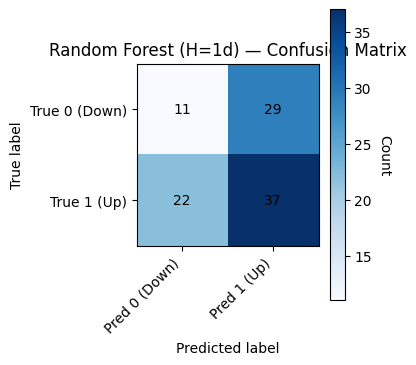

In [14]:
# ================================
# Confusion matrix heatmap — Random Forest (H=1d, real model)
# ================================
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Ensure outputs directory exists
os.makedirs("outputs", exist_ok=True)

# Use real test labels and RF predictions
y_true_real = y_test
y_pred_real = y_pred_rf

cm = confusion_matrix(y_true_real, y_pred_real)

fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(cm, cmap="Blues")

# Add colorbar
cbar = ax.figure.colorbar(im, ax=ax)
cbar.ax.set_ylabel("Count", rotation=-90, va="bottom")

# Show numbers in each cell
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            color="black",
            fontsize=10,
        )

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Pred 0 (Down)", "Pred 1 (Up)"], rotation=45, ha="right")
ax.set_yticklabels(["True 0 (Down)", "True 1 (Up)"])

ax.set_title("Random Forest (H=1d) — Confusion Matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

plt.tight_layout()

# --- SAVE PNG ---
save_path = "outputs/confusion_matrix_rf.png"
plt.savefig(save_path, dpi=300)
print(f"[Saved] {save_path}")

# --- DISPLAY ---
plt.show()

[Saved] outputs/model_comparison_rf_vs_logreg.png


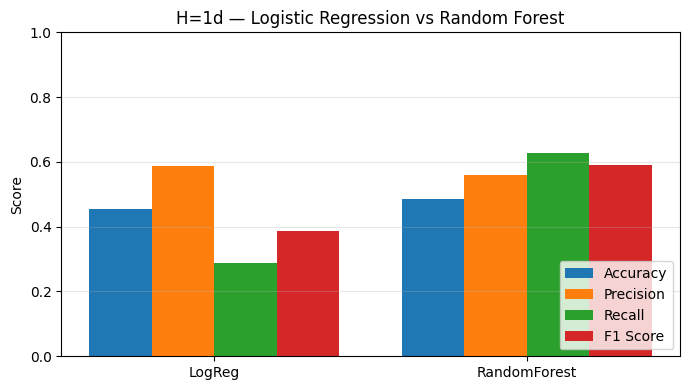

LogReg metrics: acc=0.455, prec=0.586, rec=0.288, f1=0.386
RF metrics     : acc=0.485, prec=0.561, rec=0.627, f1=0.592


In [20]:
# ============================
# RF vs Logistic — metric bar chart (REAL metrics from current run)
# ============================
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Ensure outputs directory exists
os.makedirs("outputs", exist_ok=True)

# --- Recompute metrics from real predictions ---

# Logistic Regression (logreg_clf, y_pred, y_test must exist from previous cell)
acc_lr  = accuracy_score(y_test, y_pred)
prec_lr = precision_score(y_test, y_pred)
rec_lr  = recall_score(y_test, y_pred)
f1_lr   = f1_score(y_test, y_pred)

# Random Forest (rf, y_pred_rf, y_test must exist from previous cell)
acc_rf  = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf  = recall_score(y_test, y_pred_rf)
f1_rf   = f1_score(y_test, y_pred_rf)

models = ["LogReg", "RandomForest"]

acc_vals  = [acc_lr,  acc_rf]
prec_vals = [prec_lr, prec_rf]
rec_vals  = [rec_lr,  rec_rf]
f1_vals   = [f1_lr,   f1_rf]

x = np.arange(len(models))  # positions
width = 0.2

fig, ax = plt.subplots(figsize=(7, 4))

# Bars
ax.bar(x - 1.5*width, acc_vals,  width, label="Accuracy")
ax.bar(x - 0.5*width, prec_vals, width, label="Precision")
ax.bar(x + 0.5*width, rec_vals,  width, label="Recall")
ax.bar(x + 1.5*width, f1_vals,   width, label="F1 Score")

# Labels & formatting
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1.0)
ax.set_ylabel("Score")
ax.set_title("H=1d — Logistic Regression vs Random Forest")
ax.legend(loc="lower right")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

# ---- SAVE PNG ----
save_path = "outputs/model_comparison_rf_vs_logreg.png"
plt.savefig(save_path, dpi=300)
print(f"[Saved] {save_path}")

# ---- DISPLAY ----
plt.show()

print("LogReg metrics:",
      f"acc={acc_lr:.3f}, prec={prec_lr:.3f}, rec={rec_lr:.3f}, f1={f1_lr:.3f}")
print("RF metrics     :",
      f"acc={acc_rf:.3f}, prec={prec_rf:.3f}, rec={rec_rf:.3f}, f1={f1_rf:.3f}")

[Saved] outputs/price_vs_predictions_logreg.png


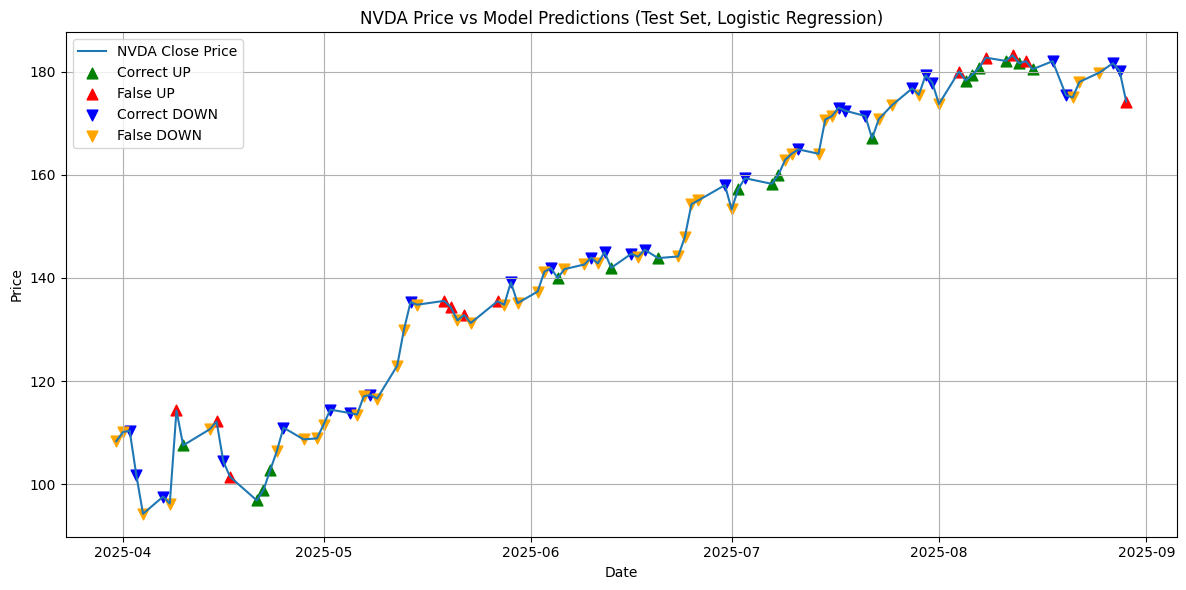

In [21]:
import os
import matplotlib.pyplot as plt

# ================================
# Price chart with model predictions (Logistic, H=1d)
# ================================

# Ensure outputs directory exists
os.makedirs("outputs", exist_ok=True)

plt.figure(figsize=(12, 6))

# 1) Price line
plt.plot(df_vis.index, df_vis["close"], label="NVDA Close Price")

# 2) Correct UP predictions (true=1, pred=1)
mask_correct_up = (df_vis["true_dir"] == 1) & (df_vis["pred_dir"] == 1)
plt.scatter(
    df_vis.index[mask_correct_up],
    df_vis["close"][mask_correct_up],
    marker="^",
    color="green",
    s=60,
    label="Correct UP"
)

# 3) Wrong UP predictions (true=0, pred=1)
mask_wrong_up = (df_vis["true_dir"] == 0) & (df_vis["pred_dir"] == 1)
plt.scatter(
    df_vis.index[mask_wrong_up],
    df_vis["close"][mask_wrong_up],
    marker="^",
    color="red",
    s=60,
    label="False UP"
)

# 4) Correct DOWN predictions (true=0, pred=0)
mask_correct_down = (df_vis["true_dir"] == 0) & (df_vis["pred_dir"] == 0)
plt.scatter(
    df_vis.index[mask_correct_down],
    df_vis["close"][mask_correct_down],
    marker="v",
    color="blue",
    s=60,
    label="Correct DOWN"
)

# 5) Wrong DOWN predictions (true=1, pred=0)
mask_wrong_down = (df_vis["true_dir"] == 1) & (df_vis["pred_dir"] == 0)
plt.scatter(
    df_vis.index[mask_wrong_down],
    df_vis["close"][mask_wrong_down],
    marker="v",
    color="orange",
    s=60,
    label="False DOWN"
)

plt.title("NVDA Price vs Model Predictions (Test Set, Logistic Regression)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.tight_layout()

# ---- SAVE PNG ----
save_path = os.path.join("outputs", "price_vs_predictions_logreg.png")
plt.savefig(save_path, dpi=300)
print(f"[Saved] {save_path}")

# ---- DISPLAY ----
plt.show()

[Saved] outputs/price_vs_predictions_rf.png


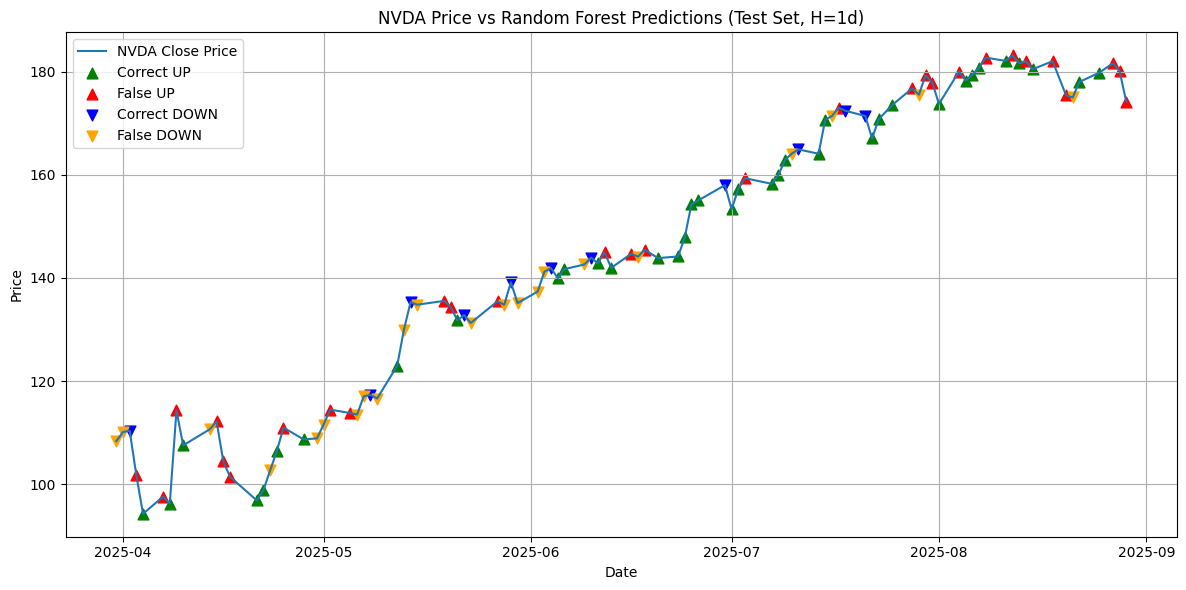

In [22]:
# ================================
# Price chart with Random Forest predictions (H=1d, real model)
# ================================
import os
import pandas as pd
import matplotlib.pyplot as plt

# Ensure outputs directory exists
os.makedirs("outputs", exist_ok=True)

# --- 1) Reconstruct test index to align with prices ---
# bin_df_model was used to build X, y in the same order
idx_all = bin_df_model.index
test_idx = idx_all[split_idx:]   # last 20% used as test

# Auto-detect close column (same logic as in feature engineering)
close_candidates = [c for c in feat.columns if c.startswith("close")]
if len(close_candidates) == 0:
    raise ValueError(f"No 'close*' column found in feat.columns: {feat.columns.tolist()}")
close_col = close_candidates[0]

# Get price series for the test window (align by index)
price_test = feat.loc[test_idx, close_col]

# Sanity check: lengths must match
if len(price_test) != len(y_test):
    raise ValueError(
        f"Length mismatch: price_test={len(price_test)}, y_test={len(y_test)}. "
        "Check that bin_df_model and feat share the same date index ordering."
    )

# Build visualization DataFrame
df_vis_rf = pd.DataFrame({
    "close": price_test,
    "true_dir": y_test,         # 0 = down, 1 = up
    "pred_dir": y_pred_rf,      # RF predicted labels
    "proba_up": y_proba_rf      # RF predicted probability of UP
}, index=price_test.index)

# --- 2) Plot price + prediction markers ---
plt.figure(figsize=(12, 6))

# 1) Price line
plt.plot(df_vis_rf.index, df_vis_rf["close"], label="NVDA Close Price")

# 2) Correct UP predictions (true=1, pred=1)
mask_correct_up = (df_vis_rf["true_dir"] == 1) & (df_vis_rf["pred_dir"] == 1)
plt.scatter(
    df_vis_rf.index[mask_correct_up],
    df_vis_rf["close"][mask_correct_up],
    marker="^",
    color="green",
    s=60,
    label="Correct UP"
)

# 3) Wrong UP predictions (true=0, pred=1)
mask_wrong_up = (df_vis_rf["true_dir"] == 0) & (df_vis_rf["pred_dir"] == 1)
plt.scatter(
    df_vis_rf.index[mask_wrong_up],
    df_vis_rf["close"][mask_wrong_up],
    marker="^",
    color="red",
    s=60,
    label="False UP"
)

# 4) Correct DOWN predictions (true=0, pred=0)
mask_correct_down = (df_vis_rf["true_dir"] == 0) & (df_vis_rf["pred_dir"] == 0)
plt.scatter(
    df_vis_rf.index[mask_correct_down],
    df_vis_rf["close"][mask_correct_down],
    marker="v",
    color="blue",
    s=60,
    label="Correct DOWN"
)

# 5) Wrong DOWN predictions (true=1, pred=0)
mask_wrong_down = (df_vis_rf["true_dir"] == 1) & (df_vis_rf["pred_dir"] == 0)
plt.scatter(
    df_vis_rf.index[mask_wrong_down],
    df_vis_rf["close"][mask_wrong_down],
    marker="v",
    color="orange",
    s=60,
    label="False DOWN"
)

plt.title("NVDA Price vs Random Forest Predictions (Test Set, H=1d)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.tight_layout()

# ---- SAVE PNG ----
save_path = os.path.join("outputs", "price_vs_predictions_rf.png")
plt.savefig(save_path, dpi=300)
print(f"[Saved] {save_path}")

# ---- DISPLAY ----
plt.show()

In [18]:
# ================================
# Build visualization DataFrame linking predictions to price
# ================================

# detect close column used earlier
close_candidates = [c for c in feat.columns if c.startswith("close")]
if len(close_candidates) == 0:
    raise ValueError("No 'close*' price column found in feat.")
close_col = close_candidates[0]

# restrict feat to the test index
df_vis = pd.DataFrame(index=idx_test)
df_vis["close"]    = feat.loc[idx_test, close_col]
df_vis["true_dir"] = y_test.values          # 0=down, 1=up
df_vis["pred_dir"] = y_pred                 # 0=down, 1=up
df_vis["proba_up"] = y_proba                # predicted probability of UP

print(df_vis.head())

                 close  true_dir  pred_dir  proba_up
date                                                
2025-03-31  108.366364         1         0  0.316407
2025-04-01  110.136147         1         0  0.453234
2025-04-02  110.406105         0         0  0.438547
2025-04-03  101.787201         0         0  0.471405
2025-04-04   94.298134         1         0  0.403669


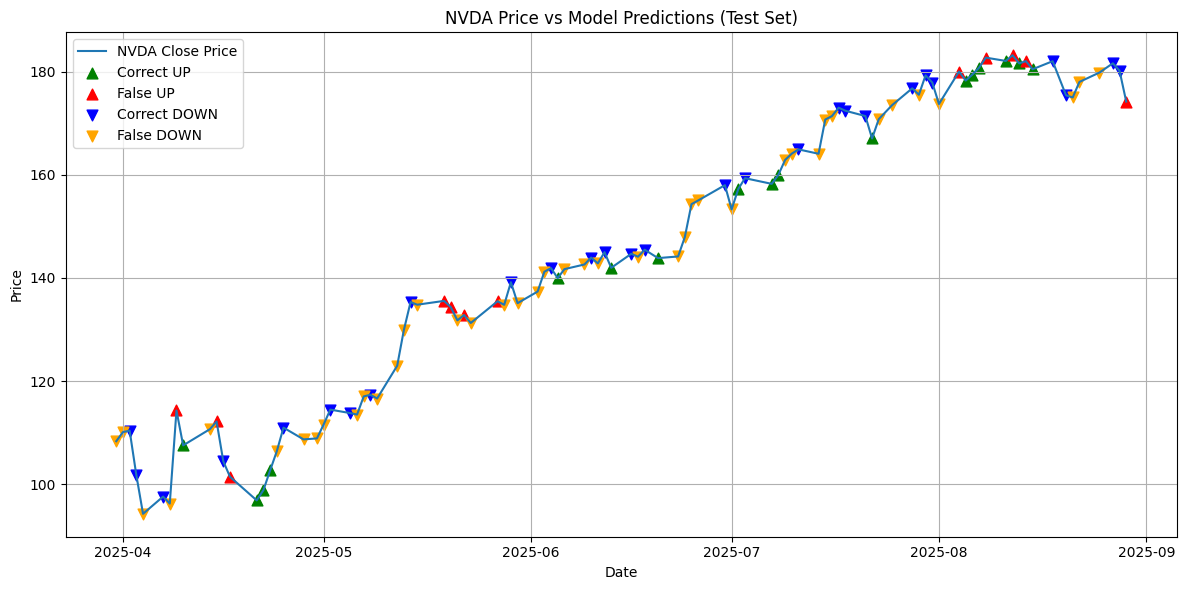

In [19]:
import matplotlib.pyplot as plt

# ================================
# Price chart with model predictions
# ================================

plt.figure(figsize=(12, 6))

# 1) Price line
plt.plot(df_vis.index, df_vis["close"], label="NVDA Close Price")

# 2) Correct UP predictions (true=1, pred=1)
mask_correct_up = (df_vis["true_dir"] == 1) & (df_vis["pred_dir"] == 1)
plt.scatter(
    df_vis.index[mask_correct_up],
    df_vis["close"][mask_correct_up],
    marker="^",
    color="green",
    s=60,
    label="Correct UP"
)

# 3) Wrong UP predictions (true=0, pred=1)
mask_wrong_up = (df_vis["true_dir"] == 0) & (df_vis["pred_dir"] == 1)
plt.scatter(
    df_vis.index[mask_wrong_up],
    df_vis["close"][mask_wrong_up],
    marker="^",
    color="red",
    s=60,
    label="False UP"
)

# 4) Correct DOWN predictions (true=0, pred=0)
mask_correct_down = (df_vis["true_dir"] == 0) & (df_vis["pred_dir"] == 0)
plt.scatter(
    df_vis.index[mask_correct_down],
    df_vis["close"][mask_correct_down],
    marker="v",
    color="blue",
    s=60,
    label="Correct DOWN"
)

# 5) Wrong DOWN predictions (true=1, pred=0)
mask_wrong_down = (df_vis["true_dir"] == 1) & (df_vis["pred_dir"] == 0)
plt.scatter(
    df_vis.index[mask_wrong_down],
    df_vis["close"][mask_wrong_down],
    marker="v",
    color="orange",
    s=60,
    label="False DOWN"
)

plt.title("NVDA Price vs Model Predictions (Test Set)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()